In [1]:
import numpy as np
from scipy.integrate import solve_ivp, ode
from scipy.optimize import fsolve, differential_evolution, minimize, root
from scipy.linalg import eig
import multiprocessing as mp
from functools import partial
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import stats

In [2]:
def system_real_general(t, y_real, order, gammas, Omega):

    A = [y_real[2*i] + 1j*y_real[2*i+1] for i in range(order)]
    rho_1 = y_real[2*order] + 1j*y_real[2*order+1]
    rho_2 = y_real[2*order+2] + 1j*y_real[2*order+3]
    
    dA_dt = [0] * order
    
    
    for k in range(order):
        if k == 0:
            dA_dt[k] = 1j * ALPHA * rho_1 * A[1] - gammas[k] * A[k] / 2 - 1j * Omega
        elif k == order - 1:
            if order % 2 == 1:
                dA_dt[k] = 1j * ALPHA * np.conj(rho_2) * A[k-1] - gammas[k] * A[k] / 2
            else: 
                dA_dt[k] = 1j * ALPHA * np.conj(rho_1) * A[k-1] - gammas[k] * A[k] / 2
        else:
            if k % 2 == 1: 
                dA_dt[k] = (1j * ALPHA * rho_2 * A[k+1] + 
                           1j * ALPHA * np.conj(rho_1) * A[k-1] - 
                           gammas[k] * A[k] / 2)
            else:  
                dA_dt[k] = (1j * ALPHA * rho_1 * A[k+1] + 
                           1j * ALPHA * np.conj(rho_2) * A[k-1] - 
                           gammas[k] * A[k] / 2)
    
    rho1_sum = 0
    rho2_sum = 0

    for k in range(0, order-1, 2):
        rho1_sum += A[k] * np.conj(A[k+1])
    
    for k in range(1, order-1, 2):
        rho2_sum += A[k] * np.conj(A[k+1])
    
    drho1_dt = 1j * BETA * rho1_sum - gammas[-2] * rho_1 / 2 + rho_1 * 1j  * ((2 * OMEGA * np.imag(gammas[0]) + np.imag(gammas[0])**2) / (2 * (OMEGA + np.imag(gammas[0]))))
    drho2_dt = 1j * BETA * rho2_sum - gammas[-1] * rho_2 / 2
    
    derivatives = []
    for dA in dA_dt:
        derivatives.extend([dA.real, dA.imag])
    derivatives.extend([drho1_dt.real, drho1_dt.imag, 
                       drho2_dt.real, drho2_dt.imag])
    
    return derivatives

def build_matrix(gammas, state, order):

    total_vars = order + 2
    d = np.concatenate((-gammas/2, -np.conj(gammas)/2))
    M = np.diag(d)
    rho1_idx = order 
    rho2_idx = order + 1
    conj_offset = total_vars
    
    for k in range(total_vars):
    
        if k == 0: 
            # Граничный случай: i=1 (нечетный)
            # ∂a_1/∂t = i*g_1*b_1*a_2 - γ_1/2*a_1 - i*E*exp(-iω_1*t)
            
            M[k, 1] = 1j * ALPHA * state[rho1_idx]  # при δa_2: коэфф. i*g_1*b_1^0
            M[k, rho1_idx] = 1j * ALPHA * state[1]  # при δb_1: коэфф. i*g_1*a_2^0

            M[k+conj_offset, 1+conj_offset] = -1j * ALPHA * np.conj(state[rho1_idx])
            M[k+conj_offset, rho1_idx+conj_offset] = -1j * ALPHA * np.conj(state[1])
   
        elif k == total_vars - 3:
            if (order % 2 == 0):  # N четный -> используем b_1^*
                M[k, rho1_idx+conj_offset] = 1j * ALPHA * state[k-1]
                M[k, k-1] = 1j * ALPHA * np.conj(state[rho1_idx])
                M[k+conj_offset, rho1_idx] = -1j * ALPHA * np.conj(state[k-1])
                M[k+conj_offset, k-1+conj_offset] = -1j * ALPHA * (state[rho1_idx])

            else:  # N нечетный -> используем b_2^*
                M[k, rho2_idx+conj_offset] = 1j * ALPHA * state[k-1]
                M[k, k-1] = 1j * ALPHA * np.conj(state[rho2_idx])
                M[k+conj_offset, rho2_idx] = -1j * ALPHA * np.conj(state[k-1])
                M[k+conj_offset, k-1+conj_offset] = -1j * ALPHA * (state[rho2_idx])

        elif k == rho1_idx:
            # ∂b_1/∂t = i*g_1*Σ_{j odd} a_j*a_{j+1}^* - Γ_1/2*b_1
            # Линеаризация: i*g_1*Σ(a_j^0*δa_{j+1}^* + a_{j+1}^{0*}*δa_j)
            
            for i in np.arange(1, total_vars-2, 2):  # i = 1, 3, 5, ... (нечетные)
                M[k, i-1] = 1j * BETA * np.conj(state[i])  # при δa_j: коэфф. i*g_1*a_{j+1}^{0*}
                M[k, i + conj_offset] = 1j * BETA * state[i-1]  # при δa_{j+1}^*: коэфф. i*g_1*a_j^0

                M[k+conj_offset, i-1 + conj_offset] = -1j * BETA * state[i]
                M[k+conj_offset, i] = -1j * BETA * np.conj(state[i-1])
            
        elif k == rho2_idx:
            # ∂b_2/∂t = i*g_2*Σ_{j even} a_j*a_{j+1}^* - Γ_2/2*b_2
            
            for j in np.arange(2, total_vars-2, 2):  # j = 2, 4, 6, ... (четные)
                M[k, j-1] = 1j * BETA * np.conj(state[j])
                M[k, j + conj_offset] = 1j * BETA * state[j-1]

                M[k+conj_offset, j-1 + conj_offset] = -1j * BETA * state[j]
                M[k+conj_offset, j] = -1j * BETA * np.conj(state[j-1])
        
        else:
            # Общий случай для внутренних мод
            
            if k % 2 == 1:  # k=1,3,5,... в Python → i=2,4,6,... четные в математике
                # ∂aᵢ/∂t = ig₂b₂aᵢ₊₁ + ig₁b₁*aᵢ₋₁
                M[k, rho2_idx] = 1j * ALPHA * state[k+1]
                M[k, k+1] = 1j * ALPHA * state[rho2_idx]
                M[k, rho1_idx+conj_offset] = 1j * ALPHA * state[k-1]
                M[k, k-1] = 1j * ALPHA * np.conj(state[rho1_idx])
                
                # Конъюгированная часть
                M[k+conj_offset, rho2_idx+conj_offset] = -1j * ALPHA * np.conj(state[k+1])
                M[k+conj_offset, k+1+conj_offset] = -1j * ALPHA * np.conj(state[rho2_idx])
                M[k+conj_offset, rho1_idx] = -1j * ALPHA * np.conj(state[k-1])
                M[k+conj_offset, k-1+conj_offset] = -1j * ALPHA * state[rho1_idx]

            elif k % 2 == 0:  # k=0,2,4,... в Python → i=1,3,5,... нечетные в математике
                # ∂aᵢ/∂t = ig₁b₁aᵢ₊₁ + ig₂b₂*aᵢ₋₁
                M[k, rho1_idx] = 1j * ALPHA * state[k+1]
                M[k, k+1] = 1j * ALPHA * state[rho1_idx]
                M[k, rho2_idx+conj_offset] = 1j * ALPHA * state[k-1]
                M[k, k-1] = 1j * ALPHA * np.conj(state[rho2_idx])
                
                # Конъюгированная часть
                M[k+conj_offset, rho1_idx+conj_offset] = -1j * ALPHA * np.conj(state[k+1])
                M[k+conj_offset, k+1+conj_offset] = -1j * ALPHA * np.conj(state[rho1_idx])
                M[k+conj_offset, rho2_idx] = -1j * ALPHA * np.conj(state[k-1])
                M[k+conj_offset, k-1+conj_offset] = -1j * ALPHA * state[rho2_idx]

    return M

def disp_offset(order, ksi=0):
        r = np.zeros(order)
	
        for n in range(order):
	    
            r[n] = (n) * ksi

        return 1j * np.array(r)
        # return 1j * np.full(order-3, ksi) 
        # return 1j * np.random.normal(0, 1, order-3) * ksi

def solve_ODE(Omega, order, gammas, t_span, t_eval, initial_conditions):
    
    sol = solve_ivp(
        lambda t, y: system_real_general(t, y, order, gammas, Omega),
        t_span,
        initial_conditions,
        t_eval=t_eval,
        method='LSODA',
        rtol=1e-8,
        atol=1e-8
    )

    return sol.y

def solve_system(Omega, order, gammas, initial_conditions):

    sol = root(lambda y: system_real_general(0, y, order, gammas, Omega),
                    initial_conditions,
                    method='lm',
                    tol=1e-14)['x']
    
    return sol

def pack_to_complex(arr):
    packed = []
    for j in range(int(len(arr) / 2)):
        real_part = arr[2*j]
        imag_part = arr[2*j + 1]
        packed.append(real_part + 1j * imag_part)
    
    return np.array(packed)

def unpack_complex(arr):
    unpacked = []
    for j in range(len(arr)):
        complex_num = arr[j]
        unpacked.append(complex_num.real)
        unpacked.append(complex_num.imag)
    
    return np.array(unpacked)

def freeze_amps(state_y, t_eval, order):
    frozen = []
    
    def find_frequency_zero_crossing(signal, sampling_rate):
        zero_crossings = np.where(np.diff(np.sign(signal)))[0]
        
        if len(zero_crossings) < 2:
            return 0
        
        periods = np.diff(zero_crossings) / sampling_rate
        average_period = np.mean(periods)
        
        frequency_hz = 1 / (2 * average_period) 
        frequency_rad = 2 * np.pi * frequency_hz 
        
        return frequency_rad

    def has_significant_oscillations(signal, threshold=0.1):
        std_dev = np.std(np.real(signal))
        mean_amp = np.mean(np.abs(np.real(signal)))
        
        return std_dev > threshold * mean_amp

    total_time = t_eval[-1] - t_eval[0]
    cutoff_time = total_time * 1/5
    mask = t_eval >= cutoff_time
    t_eval_masked = t_eval[mask]
    dt = t_eval[1] - t_eval[0]
    sampling_rate = 1 / dt

    for i, signal in enumerate(state_y):
        freq_rad = find_frequency_zero_crossing(np.real(signal[mask]), sampling_rate)
        
        if freq_rad != 0:
            compensated_signal_1 = signal * np.exp(1j * freq_rad * t_eval)
        else:
            compensated_signal_1 = signal
        
        if freq_rad != 0 and has_significant_oscillations(compensated_signal_1[mask]):
            
            compensated_signal_2 = signal * np.exp(-1j * freq_rad * t_eval)
            
            oscillations_1 = np.std(np.real(compensated_signal_1[mask]))
            oscillations_2 = np.std(np.real(compensated_signal_2[mask]))

            if oscillations_2 < oscillations_1:
                final_signal = compensated_signal_2
            else:
                final_signal = compensated_signal_1
        else:
            final_signal = compensated_signal_1
        
        frozen.append(final_signal)

    return frozen

def calculate_S(M, omega, D):

    inv1 = np.linalg.inv(np.conj(M) - 1j * omega * np.eye(M.shape[0]))
    inv2 = np.linalg.inv(M.T + 1j * omega * np.eye(M.shape[0]))
    S_omega = inv1 @ D @ inv2
    return S_omega

def plot_steady_amps(solution, Omega_values, omega_first=None, omega_second=None, order=None, stability=None, title_suffix="", _type='ODE'):
    
    fig = go.Figure()

    if omega_first is not None:
        fig.add_vline(x=abs(omega_first), line_dash="dash", line_color="red")
    
    if omega_second is not None:
        fig.add_vline(x=abs(omega_second), line_dash="dash", line_color="blue")

    if not isinstance(solution, list):
        solution = [solution]
    
    if not isinstance(_type, list):
        _type = [_type] * len(solution)
    
    max_amp_idx = 0
    
    for sol_idx, (sol, sol_type) in enumerate(zip(solution, _type)):
        
        for amp_idx in range(order + 2 if order is not None else 10): 
            final_values = []
            
            for i, amp_data in enumerate(sol):
                if amp_data is not None and len(amp_data) > amp_idx:
                    if sol_type == 'ODE':
                        final_values.append(np.abs(amp_data[amp_idx][-1]))
                    else: 
                        final_values.append(np.abs(amp_data[amp_idx]))
            
            if final_values:
                max_amp_idx = amp_idx
                trace_name = f'Sol{sol_idx+1}_A{amp_idx+1}' if len(solution) > 1 else f'A{amp_idx+1}'
                
                fig.add_trace(
                    go.Scatter(
                        x=Omega_values,
                        y=final_values,
                        mode='lines+markers',
                        name=trace_name,
                        line=dict(width=2),
                        marker=dict(size=6)
                    )
                )

    if stability is not None:
        fig.add_trace(go.Scatter(
            x=Omega_values,
            y=stability,
            name='Stability',
            line=dict(dash='dot', color='black'),
            opacity=0.7
        ))

    fig.update_layout(
        title=f'Final Amplitude Values vs Ω {title_suffix}'.strip(),
        xaxis_title='Ω',
        yaxis_title='Final Amplitude |A|',
        template='plotly_white',
        height=600,
        width=800,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    fig.show()

    pass

def calculate_max_ev(M):

    ev = max(np.real(np.linalg.eigvals(M)))

    return ev

def solve_for_initial_array(arr, Omega_values, order, gammas, t_span = None, t_eval=None, _type='system', step="straight"):

    amps = []

    for i, initial_cond in enumerate(arr):

        if step == 'straight':
            Omega = Omega_values[i]

        elif step == 'reversed':
            Omega = Omega_values[-(i+1)]

        if _type == 'system':
            solution = solve_system(Omega, order, gammas, unpack_complex(initial_cond))

        elif _type == 'ODE':
            solution = solve_ODE(Omega, order, gammas, t_span, t_eval, unpack_complex(initial_cond))

        amps.append(pack_to_complex(solution))
    
    return amps


In [10]:
# Файл: Амплитуды и стабильность (первые 5 амплитуд и evs)
with open('pho.dat', 'w') as f:
    # Заголовок в формате комментария
    f.write('# Omega pho_1 pho_2 3 4 5 6 7 8 9\n')
    
    for i, Omega in enumerate(Omega_values):
        if i < len(amps2) and amps2[i] is not None:
            # Численные значения первых 5 амплитуд
            num_values = []
            for amp_idx in range(31):  # Только первые 5 амплитуд
                if len(amps2[i]) > amp_idx:
                    if isinstance(amps2[i][amp_idx], (list, np.ndarray)) and len(amps2[i][amp_idx]) > 0:
                        # Для ODE типа берем последнее значение
                        num_values.append(np.abs(amps2[i][amp_idx][-1]))
                    else:
                        num_values.append(np.abs(amps2[i][amp_idx]))
                else:
                    num_values.append(0.0)
            
            # Значение максимальной вещественной части собственного значения
            # stability_val = evs[i] / 5
            
            # Запись с пробелами как разделителями
            f.write(f'{Omega:.6f} ')
            f.write(' '.join(f'{val:.6f}' for val in num_values))
            f.write('\n')

print("Файл amplitudes_stability_5amps.dat создан")
print("Содержит: Omega, max_Re_lambda, численные A1, A2, A3, A4, A5")
print("Для загрузки в Mathematica: data = Import[\"amplitudes_stability.dat\", \"Table\"]")

Файл amplitudes_stability_5amps.dat создан
Содержит: Omega, max_Re_lambda, численные A1, A2, A3, A4, A5
Для загрузки в Mathematica: data = Import["amplitudes_stability.dat", "Table"]


In [16]:
np.random.seed(42)
omega_0 = 1e5
ALPHA = 1e-7 * omega_0
BETA = 1e-7 * omega_0
OMEGA = 1e-4 * omega_0

num_rhos = 2
order = 31
gammas = np.concatenate((
    np.full(order, 1e-6)* omega_0,
    # np.full(order, 1e-6) * omega_0 + 1j*np.full(order, omega_0) - 1j*np.array([OMEGA*i for i in range(order)]),
    np.full(2, 1e-7) * omega_0
), dtype='complex128')


omega_first = np.real(np.real(np.real(np.real(gammas[0])))) / 2 * np.abs(-1j * np.sqrt( gammas[0] * gammas[-1] / (4 * ALPHA * BETA) ) )
t_span = (0, 200/gammas[0].real)
t_eval = np.linspace(0, 200/gammas[0].real, int(1e4))
Omega_values = np.linspace(0, 4, 100)
Omega_values = np.flip(Omega_values)

D_matrix = np.diag(np.concatenate((np.full(order, 0), [10,10], np.full(order, 0), [10,10]))) 

omega_range = np.linspace(-5, 5, 1000) * OMEGA

In [7]:
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

def calculate_single_slice(Omega_idx, Omega_values, omega_range, gammas, amps, order, D, OMEGA):
    max_shift = OMEGA * order
    step = omega_range[1] - omega_range[0]
    omega_ext = np.linspace(omega_range[0] - max_shift, 
                           omega_range[-1] + max_shift, 
                           len(omega_range) + 2 * int(max_shift / step))
    
    state = np.array(amps)[-(Omega_idx+1), :, -1]
    M = build_matrix(gammas, state, order)
    
    S_data_raw = []
    for w in omega_ext:
        S_w = calculate_S(M, w, D)
        S_data_raw.append(np.real(np.diag(S_w)))

    S_data_raw = np.array(S_data_raw)
    
    even_sum = np.zeros(len(omega_ext))
    odd_sum = np.zeros(len(omega_ext))
    
    for diag_idx in range(S_data_raw.shape[1]):

        if diag_idx >= order or diag_idx == 0:
            continue

        harmonic_number = diag_idx - 1 
        carrier_freq = -harmonic_number * OMEGA
        shift_idx = int(round(carrier_freq / step))
        
        spectrum_slow = S_data_raw[:, diag_idx]
        shifted_spectrum = np.zeros(len(omega_ext))
        
        if shift_idx >= 0:
            shifted_spectrum[shift_idx:] = spectrum_slow[:len(omega_ext)-shift_idx]
        else:
            shifted_spectrum[:shift_idx] = spectrum_slow[-shift_idx:]
            
        if harmonic_number % 2 == 0:
            even_sum += shifted_spectrum
        else:
            odd_sum += shifted_spectrum
            
    return omega_ext, even_sum, odd_sum, Omega_values[Omega_idx]

def run_full_analysis(Omega_values, omega_range, gammas, amps, order, D, OMEGA, slice_indices, output_dir="spectral_results"):
    os.makedirs(output_dir, exist_ok=True)
    
    
    for idx in slice_indices:
        w_ext, even, odd, val_O = calculate_single_slice(idx, Omega_values, omega_range, 
                                                        gammas, amps, order, D, OMEGA)
        total = even + odd
        x_limit_min = min(w_ext)
        x_limit_max = max(w_ext)
        
        mask_save = (w_ext >= x_limit_min) & (w_ext <= x_limit_max)
        
        # Сохранение EVEN в логарифме
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_EVEN_log.dat"), 
                   np.column_stack((w_ext[mask_save], np.log10(even[mask_save] + 1e-12))),
                   header=f"Omega={val_O} EVEN SHIFTS (logarithmic)\nomega\tlog10_tr_Re_S_even")
        
        # Сохранение EVEN в линейном виде
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_EVEN_linear.dat"), 
                   np.column_stack((w_ext[mask_save], even[mask_save])),
                   header=f"Omega={val_O} EVEN SHIFTS (linear)\nomega\ttr_Re_S_even")
        
        # Сохранение ODD в логарифме
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_ODD_log.dat"), 
                   np.column_stack((w_ext[mask_save], np.log10(odd[mask_save] + 1e-12))),
                   header=f"Omega={val_O} ODD SHIFTS (logarithmic)\nomega\tlog10_tr_Re_S_odd")
        
        # Сохранение ODD в линейном виде
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_ODD_linear.dat"), 
                   np.column_stack((w_ext[mask_save], odd[mask_save])),
                   header=f"Omega={val_O} ODD SHIFTS (linear)\nomega\ttr_Re_S_odd")
        
        # Сохранение TOTAL в логарифме
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_TOTAL_log.dat"), 
                   np.column_stack((w_ext[mask_save], np.log10(total[mask_save] + 1e-12))),
                   header=f"Omega={val_O} TOTAL (EVEN + ODD) (logarithmic)\nomega\tlog10_tr_Re_S_total")
        
        # Сохранение TOTAL в линейном виде
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_TOTAL_linear.dat"), 
                   np.column_stack((w_ext[mask_save], total[mask_save])),
                   header=f"Omega={val_O} TOTAL (EVEN + ODD) (linear)\nomega\ttr_Re_S_total")

        fig_log = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                              subplot_titles=(f"Even Shifts (log10) | Ω={val_O:.4f}", "Odd Shifts (log10)"))
        
        fig_log.add_trace(go.Scatter(x=w_ext, y=np.log10(even + 1e-60), name="Even", line=dict(color='blue')), row=1, col=1)
        fig_log.add_trace(go.Scatter(x=w_ext, y=np.log10(odd + 1e-60), name="Odd", line=dict(color='red')), row=2, col=1)
        
        fig_log.update_xaxes(range=[x_limit_min, x_limit_max])
        fig_log.update_layout(height=600, template="plotly_white", showlegend=False)
        display(fig_log)

        fig_int = go.Figure()
        fig_int.add_trace(go.Scatter(x=w_ext, y=total, name='tr(Re S)', fill='tozeroy', 
                                   line=dict(color='darkgreen'), fillcolor='rgba(0, 200, 0, 0.1)'))
        
        fig_int.update_xaxes(range=[x_limit_min, x_limit_max])
        fig_int.update_layout(title=f"Integrator (Linear) | Ω = {val_O:.4f}", xaxis_title="ω", yaxis_title="tr(Re S)", 
                            template="plotly_white", height=600)

        slider = widgets.FloatRangeSlider(value=[x_limit_min, x_limit_max], min=x_limit_min, max=x_limit_max,
                                        step=(w_ext[1]-w_ext[0]), description='Range:', 
                                        layout=widgets.Layout(width='100%'), continuous_update=True)
        
        output = widgets.Output()

        def on_change(change):
            with output:
                clear_output(wait=True)
                w_min, w_max = change['new']
                mask = (w_ext >= w_min) & (w_ext <= w_max)
                area = np.trapezoid(total[mask], w_ext[mask])
                print(f"Ω = {val_O:.4f} | Integral [{w_min:.4f} : {w_max:.4f}] = {area:.8e}")

        slider.observe(on_change, names='value')
        display(fig_int)
        display(slider)
        display(output)
        on_change({'new': slider.value})

run_full_analysis(np.flip(Omega_values), omega_range, gammas, amps2, order, D_matrix, OMEGA, [
    -8])

FloatRangeSlider(value=(-8.0, 8.0), description='Range:', layout=Layout(width='100%'), max=8.0, min=-8.0, step…

Output()

In [17]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import numpy as np


def _build_phase_rhs(A, B, g, e=1.0):
    N = len(A)
    g1, g2 = g[0], (g[1] if len(g) > 1 else g[0])
    B1, B2 = B[0], (B[1] if len(B) > 1 else 1.0)

    def bond_params(j):
        return (g1, B1, 0) if j % 2 == 1 else (g2, B2, 1)

    Lambda = np.zeros(N + 1)
    for j in range(1, N):
        gk, Bk, _ = bond_params(j)
        Lambda[j] = gk * Bk * A[j] / A[j - 1]

    Pi = np.zeros(N + 2)
    for j in range(2, N + 1):
        if j % 2 == 0:
            Pi[j] = g1 * B1 * A[j - 2] / A[j - 1]
        else:
            Pi[j] = g2 * B2 * A[j - 2] / A[j - 1]

    S = np.zeros(3)
    for j in range(1, N):
        gk, Bk, k = bond_params(j)
        S[k + 1] += gk / Bk * A[j - 1] * A[j]

    def F(psi):
        out = np.zeros(N + 2)
        out[0] = Lambda[1] * np.cos(psi[1]) - e * np.cos(psi[0])
        if N >= 2:
            _, _, k1 = bond_params(1)
            out[1] = (-e * np.cos(psi[0])
                      + (Lambda[1] - Pi[2] - S[k1 + 1]) * np.cos(psi[1]))
            if N >= 3:
                out[1] -= Lambda[2] * np.cos(psi[2])
        for j in range(2, N - 1):
            _, _, k = bond_params(j)
            out[j] = (Pi[j] * np.cos(psi[j - 1])
                      + (Lambda[j] - Pi[j + 1] - S[k + 1]) * np.cos(psi[j])
                      - Lambda[j + 1] * np.cos(psi[j + 1]))
        if N >= 3:
            j = N - 1
            _, _, k = bond_params(j)
            out[j] = (Pi[j] * np.cos(psi[j - 1])
                      + (Lambda[j] - Pi[j + 1] - S[k + 1]) * np.cos(psi[j]))
        for j in range(1, N):
            gk, Bk, k = bond_params(j)
            out[N + k] += gk / Bk * A[j - 1] * A[j] * np.cos(psi[j])
        return out

    return F


def _numerical_jacobian(F, x0, eps=1e-7):
    n = len(x0)
    J = np.zeros((n, n))
    for j in range(n):
        xp, xm = x0.copy(), x0.copy()
        xp[j] += eps
        xm[j] -= eps
        J[:, j] = (F(xp) - F(xm)) / (2.0 * eps)
    return J


def compute_diffusion_coefficients(A, B, g, D0, numerical_jacobian=False):
    N = len(A)
    if N <= 1:
        return np.zeros(N)
    g1, g2 = g[0], (g[1] if len(g) > 1 else g[0])
    B1, B2 = B[0], (B[1] if len(B) > 1 else 1.0)
    D01, D02 = D0[0], (D0[1] if len(D0) > 1 else 0.0)

    def bond_params(j):
        return (g1, B1, 0) if j % 2 == 1 else (g2, B2, 1)

    if numerical_jacobian:
        F = _build_phase_rhs(A, B, g)
        x0 = np.full(N + 2, np.pi / 2)
        J = _numerical_jacobian(F, x0)
        Mpp = J[:N, :N]
        Mrho = J[N:N + 2, :N]
    else:
        Lambda = np.zeros(N + 1)
        for j in range(1, N):
            gk, Bk, _ = bond_params(j)
            Lambda[j] = gk * Bk * A[j] / A[j - 1]
        Pi = np.zeros(N + 2)
        for j in range(2, N + 1):
            if j % 2 == 0:
                Pi[j] = g1 * B1 * A[j - 2] / A[j - 1]
            else:
                Pi[j] = g2 * B2 * A[j - 2] / A[j - 1]
        S = np.zeros(3)
        for j in range(1, N):
            gk, Bk, k = bond_params(j)
            S[k + 1] += gk / Bk * A[j - 1] * A[j]
        Mpp = np.zeros((N, N))
        Mpp[0, 0] = 1.0
        Mpp[0, 1] = -Lambda[1]
        Mpp[1, 0] = 1.0
        _, _, k1 = bond_params(1)
        Mpp[1, 1] = -(Lambda[1] - Pi[2] - S[k1 + 1])
        if N >= 3:
            Mpp[1, 2] = Lambda[2]
        for j in range(2, N - 1):
            _, _, k = bond_params(j)
            Mpp[j, j - 1] = -Pi[j]
            Mpp[j, j] = -(Lambda[j] - Pi[j + 1] - S[k + 1])
            Mpp[j, j + 1] = Lambda[j + 1]
        if N >= 3:
            j = N - 1
            _, _, k = bond_params(j)
            Mpp[j, j - 1] = -Pi[j]
            Mpp[j, j] = -(Lambda[j] - Pi[j + 1] - S[k + 1])
        Mrho = np.zeros((2, N))
        for j in range(1, N):
            gk, Bk, k = bond_params(j)
            Mrho[k, j] = -(gk / Bk) * A[j - 1] * A[j]

    try:
        mu = -np.linalg.inv(Mpp)
    except np.linalg.LinAlgError:
        return np.zeros(N)

    Dpsi = np.zeros(N)
    for j in range(1, N):
        _, Bk, k = bond_params(j)
        Dpsi[j] = D0[k] / Bk ** 2

    A_mat = (mu * Dpsi[np.newaxis, :]) @ mu.T

    Deff_rho = np.zeros((2, 2))
    Deff_rho[0, 0] = D01 / B1 ** 2
    Deff_rho[1, 1] = D02 / B2 ** 2
    for k in range(2):
        for l in range(2):
            Deff_rho[k, l] += Mrho[k, :] @ A_mat @ Mrho[l, :]

    Deff_photon = np.zeros(N)
    for m in range(1, N + 1):
        n1 = m // 2
        n2 = (m - 1) // 2
        c1, c2 = float(-n1), float(-n2)
        Deff_photon[m - 1] = (c1 ** 2 * Deff_rho[0, 0] +
                               c2 ** 2 * Deff_rho[1, 1] +
                               2.0 * c1 * c2 * Deff_rho[0, 1])
    return Deff_photon


def calculate_single_slice(Omega_idx, Omega_values, omega_range, gammas, amps, order, D, OMEGA,
                           numerical_jacobian=False, normalize_lorentzians=False):
    max_shift = OMEGA * order
    step = omega_range[1] - omega_range[0]
    omega_ext = np.linspace(omega_range[0] - max_shift,
                            omega_range[-1] + max_shift,
                            len(omega_range) + 2 * int(max_shift / step))

    state = np.array(amps)[-(Omega_idx + 1), :, -1]
    N = order
    A = np.abs(state[:N])
    B = np.abs(state[N:N + 2])

    D_diag = np.diag(D) if hasattr(D, 'ndim') and D.ndim == 2 else np.asarray(D).ravel()
    D0 = D_diag[N:N + 2]

    Deff = compute_diffusion_coefficients(A, B, [ALPHA, BETA], D0, numerical_jacobian=numerical_jacobian)

    even_sum = np.zeros(len(omega_ext))
    odd_sum = np.zeros(len(omega_ext))

    for j in range(N):
        harmonic_number = j
        center = -harmonic_number * OMEGA
        Deff_j = max(float(Deff[j]), 0.0)
        if Deff_j == 0.0:
            continue
        lorentzian = A[j] ** 2 * (Deff_j / 2) / ((omega_ext - center) ** 2 + (Deff_j / 4) ** 2)

        # Нормировка каждого лоренциана в логарифмическом пространстве (max → 0)
        if normalize_lorentzians and Omega_values[Omega_idx] > 0.474:
            log_lor = np.log10(lorentzian + 1e-60)
            log_lor -= np.max(log_lor)
            lorentzian = 10.0 ** log_lor
        if normalize_lorentzians:
            log_lor = np.log10(lorentzian + 1e-60)
            log_lor -= 4
            lorentzian = 10.0 ** log_lor
        if harmonic_number % 2 == 0:
            even_sum += lorentzian
        else:
            odd_sum += lorentzian

    return omega_ext, even_sum, odd_sum, Omega_values[Omega_idx]


def run_full_analysis(Omega_values, omega_range, gammas, amps, order, D, OMEGA, slice_indices, output_dir="spectral_results"):
    os.makedirs(output_dir, exist_ok=True)
    for idx in slice_indices:
        w_ext, even, odd, val_O = calculate_single_slice(idx, Omega_values, omega_range,
                                                          gammas, amps, order, D, OMEGA)
        total = even + odd
        x_limit_min = min(w_ext)
        x_limit_max = max(w_ext)
        mask_save = (w_ext >= x_limit_min) & (w_ext <= x_limit_max)

        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_EVEN_log.dat"),
                   np.column_stack((w_ext[mask_save], np.log10(even[mask_save] + 1e-12))),
                   header=f"Omega={val_O} EVEN SHIFTS (logarithmic)\nomega\tlog10_tr_Re_S_even")
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_EVEN_linear.dat"),
                   np.column_stack((w_ext[mask_save], even[mask_save])),
                   header=f"Omega={val_O} EVEN SHIFTS (linear)\nomega\ttr_Re_S_even")
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_ODD_log.dat"),
                   np.column_stack((w_ext[mask_save], np.log10(odd[mask_save] + 1e-12))),
                   header=f"Omega={val_O} ODD SHIFTS (logarithmic)\nomega\tlog10_tr_Re_S_odd")
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_ODD_linear.dat"),
                   np.column_stack((w_ext[mask_save], odd[mask_save])),
                   header=f"Omega={val_O} ODD SHIFTS (linear)\nomega\ttr_Re_S_odd")
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_TOTAL_log.dat"),
                   np.column_stack((w_ext[mask_save], np.log10(total[mask_save] + 1e-12))),
                   header=f"Omega={val_O} TOTAL (EVEN + ODD) (logarithmic)\nomega\tlog10_tr_Re_S_total")
        np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_TOTAL_linear.dat"),
                   np.column_stack((w_ext[mask_save], total[mask_save])),
                   header=f"Omega={val_O} TOTAL (EVEN + ODD) (linear)\nomega\ttr_Re_S_total")

        fig_log = make_subplots(rows=2, cols=1, shared_xaxes=True,
                                subplot_titles=(f"Even Shifts (log10) | Ω={val_O:.4f}", "Odd Shifts (log10)"))
        fig_log.add_trace(go.Scatter(x=w_ext, y=np.log10(even + 1e-60), name="Even", line=dict(color='blue')), row=1, col=1)
        fig_log.add_trace(go.Scatter(x=w_ext, y=np.log10(odd + 1e-60), name="Odd", line=dict(color='red')), row=2, col=1)
        fig_log.update_xaxes(range=[x_limit_min, x_limit_max])
        fig_log.update_layout(height=600, template="plotly_white", showlegend=False)
        display(fig_log)

        fig_int = go.Figure()
        fig_int.add_trace(go.Scatter(x=w_ext, y=total, name='tr(Re S)', fill='tozeroy',
                                     line=dict(color='darkgreen'), fillcolor='rgba(0, 200, 0, 0.1)'))
        fig_int.update_xaxes(range=[x_limit_min, x_limit_max])
        fig_int.update_layout(title=f"Integrator (Linear) | Ω = {val_O:.4f}", xaxis_title="ω",
                               yaxis_title="tr(Re S)", template="plotly_white", height=600)

        slider = widgets.FloatRangeSlider(value=[x_limit_min, x_limit_max], min=x_limit_min, max=x_limit_max,
                                          step=(w_ext[1] - w_ext[0]), description='Range:',
                                          layout=widgets.Layout(width='100%'), continuous_update=True)
        output = widgets.Output()

        def on_change(change):
            with output:
                clear_output(wait=True)
                w_min, w_max = change['new']
                mask = (w_ext >= w_min) & (w_ext <= w_max)
                area = np.trapezoid(total[mask], w_ext[mask])
                print(f"Ω = {val_O:.4f} | Integral [{w_min:.4f} : {w_max:.4f}] = {area:.8e}")

        slider.observe(on_change, names='value')
        display(fig_int)
        display(slider)
        display(output)
        on_change({'new': slider.value})


def run_heatmap(Omega_values, omega_range, gammas, amps, order, D, OMEGA,
                mode='total', log_scale=True, output_dir="spectral_results"):
    os.makedirs(output_dir, exist_ok=True)

    max_shift = OMEGA * order
    step = omega_range[1] - omega_range[0]
    omega_ext = np.linspace(omega_range[0] - max_shift,
                            omega_range[-1] + max_shift,
                            len(omega_range) + 2 * int(max_shift / step))

    n_omega = len(Omega_values)
    n_freq = len(omega_ext)
    Z = np.zeros((n_freq, n_omega))

    for col, idx in enumerate(range(n_omega)):
        try:
            _, even, odd, _ = calculate_single_slice(
                idx, Omega_values, omega_range,
                gammas, amps, order, D, OMEGA,
                normalize_lorentzians=True,          # <-- включаем только для хитмэпа
            )
            if mode == 'even':
                Z[:, col] = even
            elif mode == 'odd':
                Z[:, col] = odd
            else:
                Z[:, col] = even + odd
        except Exception:
            Z[:, col] = 0.0

    if log_scale:
        Z_plot = np.log10(Z + 1e-60)
        colorbar_title = "log₁₀ S(ω)"
    else:
        Z_plot = Z
        colorbar_title = "S(ω)"

    fig = go.Figure(go.Heatmap(
        x=Omega_values,
        y=omega_ext,
        z=Z_plot,
        colorscale='Inferno',
        colorbar=dict(title=colorbar_title),
        zsmooth='best',
    ))

    mode_label = {'total': 'Total', 'even': 'Even shifts', 'odd': 'Odd shifts'}.get(mode, mode)
    scale_label = 'log₁₀' if log_scale else 'linear'
    fig.update_layout(
        title=f"Spectrum vs pump — {mode_label} ({scale_label})",
        xaxis_title="Pump Ω",
        yaxis_title="ω",
        height=600,
        template="plotly_white",
    )

    fname_base = os.path.join(output_dir, f"heatmap_{mode}_{'log' if log_scale else 'lin'}")

    np.savetxt(fname_base + ".dat", Z_plot, fmt="%.8g")

    with open(fname_base + "_axes.dat", "w") as f_ax:
        f_ax.write(f"{float(np.array(Omega_values).min()):.8g} {float(np.array(Omega_values).max()):.8g}\n")
        f_ax.write(f"{float(omega_ext.min()):.8g} {float(omega_ext.max()):.8g}\n")

    display(fig)
    return fig, omega_ext, Z


def compare_two_slices(idx_a, idx_b, Omega_values, omega_range, gammas, amps, order, D, OMEGA,
                       mode='total', log_scale=True):
    slices = {}
    for idx in (idx_a, idx_b):
        w_ext, even, odd, val_O = calculate_single_slice(idx, Omega_values, omega_range,
                                                         gammas, amps, order, D, OMEGA)
        if mode == 'even':
            spec = even
        elif mode == 'odd':
            spec = odd
        else:
            spec = even + odd
        slices[idx] = (w_ext, spec, val_O)

    w_a, s_a, O_a = slices[idx_a]
    w_b, s_b, O_b = slices[idx_b]

    if log_scale:
        y_a = np.log10(s_a + 1e-60)
        y_b = np.log10(s_b + 1e-60)
        yaxis_title = "log₁₀ S(ω)"
    else:
        y_a = s_a
        y_b = s_b
        yaxis_title = "S(ω)"

    mode_label = {'total': 'Total', 'even': 'Even shifts', 'odd': 'Odd shifts'}.get(mode, mode)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=w_a, y=y_a, name=f"Ω = {O_a:.4f}",
                             line=dict(color='royalblue', width=1.8)))
    fig.add_trace(go.Scatter(x=w_b, y=y_b, name=f"Ω = {O_b:.4f}",
                             line=dict(color='crimson', width=1.8)))
    fig.update_layout(
        title=f"Spectrum comparison — {mode_label}",
        xaxis_title="ω",
        yaxis_title=yaxis_title,
        legend=dict(x=0.01, y=0.99),
        height=500,
        template="plotly_white",
    )
    display(fig)
    return fig


run_full_analysis(np.flip(Omega_values), omega_range, gammas, amps2, order, D_matrix, OMEGA, [-1])
# run_heatmap(np.flip(Omega_values), omega_range, gammas, amps2, order, D_matrix, OMEGA)
# compare_two_slices(-50, -1, np.flip(Omega_values), omega_range, gammas, amps2, order, D_matrix, OMEGA)

FloatRangeSlider(value=(-360.0, 360.0), description='Range:', layout=Layout(width='100%'), max=360.0, min=-360…

Output()

In [9]:
def save_single_spectrum(idx, Omega_values, omega_range, gammas, amps, order, D, OMEGA,
                          output_dir="spectral_results"):
    os.makedirs(output_dir, exist_ok=True)

    w_ext, even, odd, val_O = calculate_single_slice(idx, Omega_values, omega_range,
                                                       gammas, amps, order, D, OMEGA)
    total = even + odd

    x_limit_min = min(w_ext)
    x_limit_max = max(w_ext)
    mask_save = (w_ext >= x_limit_min) & (w_ext <= x_limit_max)

    np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_EVEN_log.dat"),
               np.column_stack((w_ext[mask_save], np.log10(even[mask_save] + 1e-12))),
               header=f"Omega={val_O} EVEN SHIFTS (logarithmic)\nomega\tlog10_tr_Re_S_even")
    np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_EVEN_linear.dat"),
               np.column_stack((w_ext[mask_save], even[mask_save])),
               header=f"Omega={val_O} EVEN SHIFTS (linear)\nomega\ttr_Re_S_even")
    np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_ODD_log.dat"),
               np.column_stack((w_ext[mask_save], np.log10(odd[mask_save] + 1e-12))),
               header=f"Omega={val_O} ODD SHIFTS (logarithmic)\nomega\tlog10_tr_Re_S_odd")
    np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_ODD_linear.dat"),
               np.column_stack((w_ext[mask_save], odd[mask_save])),
               header=f"Omega={val_O} ODD SHIFTS (linear)\nomega\ttr_Re_S_odd")
    np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_TOTAL_log.dat"),
               np.column_stack((w_ext[mask_save], np.log10(total[mask_save] + 1e-12))),
               header=f"Omega={val_O} TOTAL (EVEN + ODD) (logarithmic)\nomega\tlog10_tr_Re_S_total")
    np.savetxt(os.path.join(output_dir, f"slice_O_{val_O:.4f}_TOTAL_linear.dat"),
               np.column_stack((w_ext[mask_save], total[mask_save])),
               header=f"Omega={val_O} TOTAL (EVEN + ODD) (linear)\nomega\ttr_Re_S_total")

    print(f"Сохранено для Ω={val_O:.4f} в {output_dir}/")


# Использование для последнего слайса (индекс -1):
save_single_spectrum(-1, np.flip(Omega_values), omega_range, gammas, amps2, order, D_matrix, OMEGA)

Сохранено для Ω=4.0000 в spectral_results/


In [7]:
initial_condition = np.full((order+2)*2, 1e2)
amps2 = []

flag = False
evs = []


for Omega in Omega_values:

    solution = solve_ODE(Omega, order, gammas, t_span, t_eval, initial_condition)
    if not flag:
        initial_condition1 = solution[:,-1]
        flag = True
        
    amps2.append(pack_to_complex(solution))
    print(f'completed {Omega}')
    solution[:, -1][abs(solution[:, -1]) < 1e-12] = 0
    initial_condition = solution[:, -1]
    
plot_steady_amps([np.array(amps2)], Omega_values / omega_0 * 1e5, _type=['ODE'])
# S, _ = plot_S_diagonal_heatmaps(Omega_values, omega_range, gammas, amps2, order, D_matrix)

completed 4.0
completed 3.95959595959596
completed 3.9191919191919196
completed 3.878787878787879
completed 3.8383838383838387
completed 3.7979797979797985
completed 3.757575757575758
completed 3.7171717171717176
completed 3.676767676767677
completed 3.6363636363636367
completed 3.5959595959595965
completed 3.555555555555556
completed 3.5151515151515156
completed 3.474747474747475
completed 3.4343434343434347
completed 3.393939393939394
completed 3.353535353535354
completed 3.3131313131313136
completed 3.272727272727273
completed 3.2323232323232327
completed 3.191919191919192
completed 3.151515151515152
completed 3.111111111111111
completed 3.070707070707071
completed 3.0303030303030307
completed 2.98989898989899
completed 2.94949494949495
completed 2.909090909090909
completed 2.868686868686869
completed 2.8282828282828287
completed 2.787878787878788
completed 2.747474747474748
completed 2.707070707070707
completed 2.666666666666667
completed 2.6262626262626263
completed 2.585858585858

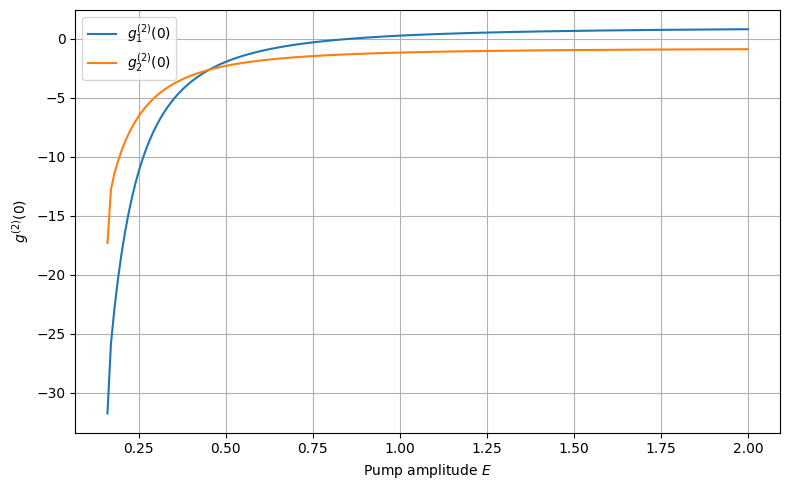

In [39]:
from scipy.linalg import solve_continuous_lyapunov
import matplotlib.pyplot as plt
import numpy as np

g2_1 = []
g2_2 = []
g2_3 = []

Gamma1 = gammas[3].real
Gamma2 = gammas[4].real

gamma1 = gammas[0].real
gamma2 = gammas[1].real
gamma3 = gammas[2].real

D1 = 1 
D2 = 1

eps = 1e-8

for amps in amps2:

    a1 = amps[0][-1]
    a2 = amps[1][-1]
    a3 = amps[2][-1]
    b1 = amps[3][-1]
    b2 = amps[4][-1]

    A1 = np.abs(a1)
    A2 = np.abs(a2)
    A3 = np.abs(a3)
    B1 = np.abs(b1)
    B2 = np.abs(b2)

    if A1 < eps or A2 < eps or A3 < eps:
        g2_1.append(np.nan)
        g2_2.append(np.nan)
        g2_3.append(np.nan)
        continue

    mu1B1 = -Gamma1 * B1**2 / (2 * A1 * A2)
    mu1A2 = -Gamma1 * B1  / (2 * A1)
    mu1A1 = -Gamma1 * B1  / (2 * A2)

    mu2B2 = -Gamma2 * B2**2 / (2 * A2 * A3)
    mu2A3 = -Gamma2 * B2  / (2 * A2)
    mu2A2 = -Gamma2 * B2  / (2 * A3)

    # Якобиан по амплитудам: Eq. (20) статьи
    MA = np.array([
        [-gamma1/2,  mu1B1,       0,        mu1A2,    0       ],
        [-mu1B1,    -gamma2/2,    mu2B2,   -mu1A1,    mu2A3   ],
        [ 0,        -mu2B2,      -gamma3/2,  0,       -mu2A2  ],
        [-mu1A2,    -mu1A1,       0,        -Gamma1/2, 0      ],
        [ 0,        -mu2A3,      -mu2A2,     0,       -Gamma2/2]
    ], dtype=np.float64)

    if np.isnan(MA).any() or np.isinf(MA).any():
        g2_1.append(np.nan)
        g2_2.append(np.nan)
        g2_3.append(np.nan)
        continue

    # --- ИСПРАВЛЕНИЕ 3: проверка устойчивости MA ---
    # Lyapunov даёт физический результат только если Re(λ) < 0 для всех λ
    eigvals = np.linalg.eigvals(MA)
    if np.any(eigvals.real >= 0):
        g2_1.append(np.nan)
        g2_2.append(np.nan)
        g2_3.append(np.nan)
        continue

    # D^(A) = diag(0, 0, 0, D1, D2)  —  Eq. (24) статьи
    D_mat = np.diag([0.0, 0.0, 0.0, D1, D2])

    # --- ИСПРАВЛЕНИЕ 4: ловим конкретное исключение, а не всё подряд ---
    try:
        # MA @ sigma + sigma @ MA.T + 2*D^(A) = 0  —  Eq. (28) статьи
        sigma = solve_continuous_lyapunov(MA, 2 * D_mat)

        # g^(2)_j(0) = 1 + 4*sigma_jj / A_j^2  —  Eq. (27) статьи
        # Храним g^(2)(0) - 1, а не g^(2)(0)
        g2_1.append(float(1+4 * sigma[0, 0] / A1**2))
        g2_2.append(float(1+4 * sigma[1, 1] / A2**2))
        g2_3.append(float(1+4 * sigma[2, 2] / A3**2))

    except np.linalg.LinAlgError as e:
        print(f"Lyapunov failed: {e}")
        g2_1.append(np.nan)
        g2_2.append(np.nan)
        g2_3.append(np.nan)

pump = Omega_values  

plt.figure(figsize=(8, 5))
plt.plot(pump, g2_1, label=r'$g_1^{(2)}(0)$')
plt.plot(pump, g2_2, label=r'$g_2^{(2)}(0)$')
plt.xlabel('Pump amplitude $E$')
plt.ylabel(r'$g^{(2)}(0)$')
E = np.array(Omega_values, dtype=float)
i0 = np.where(np.isfinite(g2_3))[0][0]     
ref = np.array(g2_3, dtype=float)
scale = ref[i0] * E[i0]**2

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

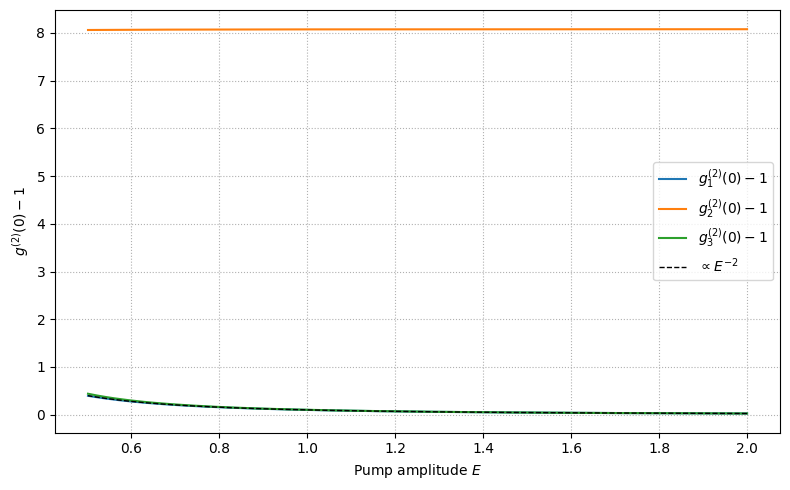

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Gamma1 = gammas[3].real
Gamma2 = gammas[4].real
gamma1 = gammas[0].real
gamma2 = gammas[1].real
gamma3 = gammas[2].real

D1 = 1.0   
D2 = 1.0   

eps = 1e-12

g2_1 = []
g2_2 = []
g2_3 = []

for amps in amps2:

    A1 = np.abs(amps[0][-1])
    A2 = np.abs(amps[1][-1])
    A3 = np.abs(amps[2][-1])
    B1 = np.abs(amps[3][-1])
    B2 = np.abs(amps[4][-1])

    if A1 < eps or A2 < eps or A3 < eps:
        g2_1.append(np.nan)
        g2_2.append(np.nan)
        g2_3.append(np.nan)
        continue

    # Q_{0,A}  —  Eq. (35)
    Q0A = (B1**2 + A2**2) * (B2**2 + A3**2) - A3**2 * B2**2

    # g^(2)_1(0) - 1  —  аналог Eq. (31)-(32) для a1 (шум через b1)
    g2_1.append(D1 / (gamma1 * A1**2))

    # g^(2)_2(0) - 1  —  Eq. (36)
    g2_2.append(
        (2*D1 / (gamma2 * A2**2)) * (1 + A2**4 / Q0A**2)
        + (2*D2 / (gamma2 * A2**2)) * (A3**4 * B2**4 / Q0A**2)
    )

    # g^(2)_3(0) - 1  —  Eq. (32)
    g2_3.append(D2 / (gamma3 * A3**2))

pump_arr = np.array(pump, dtype=float)
g2_1_arr = np.array(g2_1)
g2_2_arr = np.array(g2_2)
g2_3_arr = np.array(g2_3)

mask = (pump_arr > 0.5) & np.isfinite(g2_3_arr) & (g2_3_arr > 0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(pump_arr[mask], g2_1_arr[mask], label=r'$g_1^{(2)}(0)-1$')
ax.plot(pump_arr[mask], g2_2_arr[mask], label=r'$g_2^{(2)}(0)-1$')
ax.plot(pump_arr[mask], g2_3_arr[mask], label=r'$g_3^{(2)}(0)-1$')

i0 = np.where(mask)[0][0]
scale = g2_3_arr[i0] * pump_arr[i0]**2
ax.plot(pump_arr[mask], scale / pump_arr[mask]**2,
        'k--', lw=1, label=r'$\propto E^{-2}$')

ax.set_xlabel(r'Pump amplitude $E$')
ax.set_ylabel(r'$g^{(2)}(0) - 1$')
# ax.set_yscale('log')
ax.grid(True, which='both', ls=':')
ax.legend()
plt.tight_layout()
plt.show()

In [92]:
import csv
Omega_values = np.linspace(0, 1.5, 1000)
Omega_values = np.flip(Omega_values)
def run_omega_sweep(order, Omega_values, t_span, t_eval):
    gammas = np.concatenate((
        np.full(order, 1e-6) * omega_0,
        np.full(2, 1e-7) * omega_0
    ), dtype='complex128')

    initial_condition = np.full((order + 2) * 2, 1e1)
    amps = []
    flag = False

    for Omega in Omega_values:
        solution = solve_ODE(Omega, order, gammas, t_span, t_eval, initial_condition)
        if not flag:
            flag = True
        amps.append(pack_to_complex(solution))
        solution[:, -1][abs(solution[:, -1]) < 1e-12] = 0
        initial_condition = solution[:, -1]

    return np.array(amps), gammas


def find_threshold(amps, Omega_values):
    last_amps = np.array([np.abs(a[-1][-1]) for a in amps])
    d_last    = np.gradient(last_amps, Omega_values)
    peak_idx  = np.argmax(np.abs(d_last))
    return Omega_values[peak_idx], last_amps, d_last


# ════════════════════════════════════════════════════════════════
#  ОСНОВНОЙ ЦИКЛ: order = 3, 5, 7, ..., 25
# ════════════════════════════════════════════════════════════════

results = {}

for ord_ in range(3, 5, 2):
    print(f"--- order = {ord_} ---")

    t_span_loc = (0, 200 / (1e-6 * omega_0))
    t_eval_loc = np.linspace(*t_span_loc, int(1e4))

    amps_loc, _ = run_omega_sweep(ord_, Omega_values, t_span_loc, t_eval_loc)
    thr_loc, _, deriv_loc = find_threshold(amps_loc, Omega_values)

    last_amps_pho2  = np.array([np.abs(a[-1][-1]) for a in amps_loc])
    last_amps_pho1  = np.array([np.abs(a[-2][-1]) for a in amps_loc])
    d_pho2 = np.gradient(last_amps_pho2, Omega_values)
    d_pho1 = np.gradient(last_amps_pho1, Omega_values)
    thr_pho2 = Omega_values[np.argmax(np.abs(d_pho2))]
    thr_pho1 = Omega_values[np.argmax(np.abs(d_pho1))]

    results[ord_] = (thr_pho2, thr_pho1)
    print(f"    Ω_thr (pho2) = {thr_pho2:.6f},  Ω_thr (pho1) = {thr_pho1:.6f}")


# ════════════════════════════════════════════════════════════════
#  СОХРАНЕНИЕ В ФАЙЛ
# ════════════════════════════════════════════════════════════════

out_path = 'threshold_vs_order.dat'
with open(out_path, 'w') as f:
    f.write('# order   pho2            pho1\n')
    for ord_, (thr_pho2, thr_pho1) in sorted(results.items()):
        f.write(f'{ord_}   {thr_pho2:.10f}   {thr_pho1:.10f}\n')

print(f"\nРезультаты сохранены → {out_path}")

--- order = 3 ---
    Ω_thr (pho2) = 0.157658,  Ω_thr (pho1) = 0.079580

Результаты сохранены → threshold_vs_order.dat


In [ ]:
def system_real(t, y_real, Omega, gammas):
    A1_r, A1_i, A2_r, A2_i, A3_r, A3_i, A4_r, A4_i, A5_r, A5_i,\
    A6_r, A6_i, A7_r, A7_i, A8_r, A8_i, A9_r, A9_i,\
    rho1_r, rho1_i, rho2_r, rho2_i, rho3_r, rho3_i, rho4_r, rho4_i,\
    rho5_r, rho5_i, rho6_r, rho6_i, rho7_r, rho7_i, rho8_r, rho8_i = y_real
    
    A_1 = A1_r + 1j * A1_i
    A_2 = A2_r + 1j * A2_i
    A_3 = A3_r + 1j * A3_i
    A_4 = A4_r + 1j * A4_i
    A_5 = A5_r + 1j * A5_i
    A_6 = A6_r + 1j * A6_i
    A_7 = A7_r + 1j * A7_i
    A_8 = A8_r + 1j * A8_i
    A_9 = A9_r + 1j * A9_i

    rho_1 = rho1_r + 1j * rho1_i
    rho_2 = rho2_r + 1j * rho2_i
    rho_3 = rho3_r + 1j * rho3_i
    rho_4 = rho4_r + 1j * rho4_i
    rho_5 = rho5_r + 1j * rho5_i
    rho_6 = rho6_r + 1j * rho6_i
    rho_7 = rho7_r + 1j * rho7_i
    rho_8 = rho8_r + 1j * rho8_i

    d1dt = 1j * ALPHA * rho_1 * A_2 - gammas[0] * A_1 / 2 - 1j * Omega 
    d2dt = 1j * ALPHA * rho_2 * A_3 - gammas[1] * A_2 / 2 + 1j * ALPHA * np.conj(rho_1) * A_1
    d3dt = 1j * ALPHA * rho_3 * A_4 - gammas[2] * A_3 / 2 + 1j * ALPHA * np.conj(rho_2) * A_2
    d4dt = 1j * ALPHA * rho_4 * A_5 - gammas[3] * A_4 / 2 + 1j * ALPHA * np.conj(rho_3) * A_3
    d5dt = 1j * ALPHA * rho_5 * A_6 - gammas[4] * A_5 / 2 + 1j * ALPHA * np.conj(rho_4) * A_4
    d6dt = 1j * ALPHA * rho_6 * A_7 - gammas[5] * A_6 / 2 + 1j * ALPHA * np.conj(rho_5) * A_5
    d7dt = 1j * ALPHA * rho_7 * A_8 - gammas[6] * A_7 / 2 + 1j * ALPHA * np.conj(rho_6) * A_6
    d8dt = 1j * ALPHA * rho_8 * A_9 - gammas[7] * A_8 / 2 + 1j * ALPHA * np.conj(rho_7) * A_7
    d9dt = - gammas[8] * A_9 / 2 + 1j * ALPHA * np.conj(rho_8) * A_8

    drho1dt = 1j * BETA * (A_1 * np.conj(A_2)) - gammas[9] * rho_1 / 2
    drho2dt = 1j * BETA * (A_2 * np.conj(A_3)) - gammas[9] * rho_2 / 2
    drho3dt = 1j * BETA * (A_3 * np.conj(A_4)) - gammas[9] * rho_3 / 2
    drho4dt = 1j * BETA * (A_4 * np.conj(A_5)) - gammas[9] * rho_4 / 2
    drho5dt = 1j * BETA * (A_5 * np.conj(A_6)) - gammas[9] * rho_5 / 2
    drho6dt = 1j * BETA * (A_6 * np.conj(A_7)) - gammas[9] * rho_6 / 2
    drho7dt = 1j * BETA * (A_7 * np.conj(A_8)) - gammas[9] * rho_7 / 2
    drho8dt = 1j * BETA * (A_8 * np.conj(A_9)) - gammas[9] * rho_8 / 2
    
    derivatives = []
    for derivative in [d1dt, d2dt, d3dt, d4dt, d5dt, d6dt, d7dt, d8dt, d9dt, drho1dt, drho2dt, drho3dt, drho4dt, drho5dt, drho6dt, drho7dt, drho8dt]:
        derivatives.append(derivative.real)
        derivatives.append(derivative.imag)
    
    return derivatives

In [ ]:
# gammas = np.concatenate((
#     np.random.normal(10, 0, order),
#     np.full(2, 1)
# ), dtype='complex128')

# gammas = [10, 1]


ALPHA = 1.0
BETA = 1.0
Omega_values = np.linspace(0, 15, 100)
Omega_values = np.flip(Omega_values)

t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# amps3 = []
amps2 = []

for i, Omega in enumerate(Omega_values):
    print(f"Solving for Omega = {Omega:.2f}")

    if i == 0:
        # initial_conditions = np.ones((order+2)*2) * 10
        initial_conditions = np.ones(4*order-2) * 10

    
    # sol = solve_ivp(
    #     system_real_general, 
    #     t_span, 
    #     initial_conditions, 
    #     args=(order, gammas, Omega),
    #     t_eval=t_eval,
    #     method='LSODA',
    #     rtol=1e-9,
    #     atol=1e-9
        
    # )

    sol = solve_ivp(
        system_real, 
        t_span, 
        initial_conditions, 
        args=(Omega, gammas),
        t_eval=t_eval,
        method='LSODA',
        rtol=1e-9,
        atol=1e-9
        
    )

    # initial_conditions = list(sol.y[j][-1] for j in range((order+2)*2))
    initial_conditions = list(sol.y[j][-1] for j in range(4*order-2))

    A1_complex = sol.y[0] + 1j * sol.y[1]
    A2_complex = sol.y[2] + 1j * sol.y[3]
    A3_complex = sol.y[4] + 1j * sol.y[5]
    A4_complex = sol.y[6] + 1j * sol.y[7]
    A5_complex = sol.y[8] + 1j * sol.y[9]
    A6_complex = sol.y[10] + 1j * sol.y[11]
    A7_complex = sol.y[12] + 1j * sol.y[13]
    A8_complex = sol.y[14] + 1j * sol.y[15]
    A9_complex = sol.y[16] + 1j * sol.y[17]

    rho1_complex = sol.y[18] + 1j * sol.y[19]
    rho2_complex = sol.y[20] + 1j * sol.y[21]

    rho3_complex = sol.y[22] + 1j * sol.y[23]
    rho4_complex = sol.y[24] + 1j * sol.y[25]
    rho5_complex = sol.y[26] + 1j * sol.y[27]
    rho6_complex = sol.y[28] + 1j * sol.y[29]
    rho7_complex = sol.y[30] + 1j * sol.y[31]
    rho8_complex = sol.y[32] + 1j * sol.y[33]


    # a = np.array([
    #     A1_complex, A2_complex, A3_complex, A4_complex, A5_complex, A6_complex, A7_complex, A8_complex, A9_complex, 
    #     rho1_complex, rho2_complex
    # ])

    a = np.array([
        A1_complex, A2_complex, A3_complex, A4_complex, A5_complex, A6_complex, A7_complex, A8_complex, A9_complex, 
        rho1_complex, rho2_complex, rho3_complex, rho4_complex, rho5_complex, rho6_complex, rho7_complex, rho8_complex
    ])


    # amps3.append(a)

    amps2.append(a)

    print(f"Completed Omega = {Omega:.2f}")

Solving for Omega = 15.00


IndexError: index 19 is out of bounds for axis 0 with size 19

In [107]:
N_PHOTONS = 7         # A_1 … A_23
N_PHONONS = N_PHOTONS - 1  # rho_1 … rho_22
# state vector length:  (N_PHOTONS + N_PHONONS) * 2  =  90

# ── ODE right-hand side ──────────────────────────────────────────────────────
def system_real(t, y_real, Omega, gammas):
    """
    y_real layout (all real):
        A_1.re, A_1.im,  A_2.re, A_2.im,  …,  A_23.re, A_23.im,   (indices 0–45)
        rho_1.re, rho_1.im,  …,  rho_22.re, rho_22.im             (indices 46–89)

    gammas layout (length N_PHOTONS + 1 = 24):
        gammas[0..N_PHOTONS-1]  →  photon decay rates
        gammas[N_PHOTONS]       →  common phonon decay rate
    """
    # --- unpack complex amplitudes -------------------------------------------
    A   = np.array([y_real[2*k]   + 1j * y_real[2*k+1]   for k in range(N_PHOTONS)])
    rho = np.array([y_real[2*N_PHOTONS + 2*k] + 1j * y_real[2*N_PHOTONS + 2*k+1]
                    for k in range(N_PHONONS)])

    # --- photon equations (A index: 0-based) ---------------------------------
    dAdt = np.empty(N_PHOTONS, dtype=complex)

    # k = 0  (A_1 in the paper)
    dAdt[0] = (  1j * ALPHA * rho[0] * A[1]
               - gammas[0] * A[0] / 2
               - 1j * Omega )

    # k = 1 … N_PHOTONS-2  (interior modes)
    for k in range(1, N_PHOTONS - 1):
        dAdt[k] = (  1j * ALPHA * rho[k] * A[k+1]
                   - gammas[k] * A[k] / 2
                   + 1j * ALPHA * np.conj(rho[k-1]) * A[k-1] )

    # k = N_PHOTONS-1  (last photon, A_23)
    dAdt[-1] = (- gammas[N_PHOTONS-1] * A[-1] / 2
                + 1j * ALPHA * np.conj(rho[-1]) * A[-2] )

    # --- phonon equations ----------------------------------------------------
    gamma_rho = gammas[N_PHOTONS]          # single decay rate for all phonons
    drhodt = np.array([
        1j * BETA * A[k] * np.conj(A[k+1]) - gamma_rho * rho[k] / 2
        for k in range(N_PHONONS)
    ])

    # --- pack real output -----------------------------------------------------
    derivatives = []
    for dz in list(dAdt) + list(drhodt):
        derivatives.append(dz.real)
        derivatives.append(dz.imag)

    return derivatives


# ── gammas ───────────────────────────────────────────────────────────────────
gammas = np.array(
    [1e-6* omega_0] * N_PHOTONS + [1e-7 * omega_0],   # 23 photon rates + 1 phonon rate
    dtype='complex128'
)
# ── sweep ────────────────────────────────────────────────────────────────────
STATE_DIM      = (N_PHOTONS + N_PHONONS) * 2   # = 90

amps2 = []
Omega_values = np.linspace(0, 2, 100)
Omega_values = np.flip(Omega_values)
for i, Omega in enumerate(Omega_values):
    print(f"Solving for Omega = {Omega:.4f}")

    if i == 0:
        initial_conditions = np.ones(STATE_DIM) * 10.0

    sol = solve_ivp(
        system_real,
        t_span,
        initial_conditions,
        args=(Omega, gammas),
        t_eval=t_eval,
        method='LSODA',
        rtol=1e-8,
        atol=1e-8,
    )
    last_state = sol.y[:, -1].copy()
    last_state[np.abs(last_state) < 1e-10] = 0.0
    initial_conditions = last_state.tolist()

    # --- reconstruct complex time-series -------------------------------------
    A_complex = np.array([
        sol.y[2*k] + 1j * sol.y[2*k+1]
        for k in range(N_PHOTONS)
    ])                                   # shape (23, 1000)

    rho_complex = np.array([
        sol.y[2*N_PHOTONS + 2*k] + 1j * sol.y[2*N_PHOTONS + 2*k+1]
        for k in range(N_PHONONS)
    ])                                   # shape (22, 1000)

    a = np.vstack([A_complex, rho_complex])   # shape (45, 1000)
    amps2.append(a)

    print(f"  ✓  Omega = {Omega:.4f}  done")

Solving for Omega = 2.0000
  ✓  Omega = 2.0000  done
Solving for Omega = 1.9798
  ✓  Omega = 1.9798  done
Solving for Omega = 1.9596
  ✓  Omega = 1.9596  done
Solving for Omega = 1.9394
  ✓  Omega = 1.9394  done
Solving for Omega = 1.9192
  ✓  Omega = 1.9192  done
Solving for Omega = 1.8990
  ✓  Omega = 1.8990  done
Solving for Omega = 1.8788
  ✓  Omega = 1.8788  done
Solving for Omega = 1.8586
  ✓  Omega = 1.8586  done
Solving for Omega = 1.8384
  ✓  Omega = 1.8384  done
Solving for Omega = 1.8182
  ✓  Omega = 1.8182  done
Solving for Omega = 1.7980
  ✓  Omega = 1.7980  done
Solving for Omega = 1.7778
  ✓  Omega = 1.7778  done
Solving for Omega = 1.7576
  ✓  Omega = 1.7576  done
Solving for Omega = 1.7374
  ✓  Omega = 1.7374  done
Solving for Omega = 1.7172
  ✓  Omega = 1.7172  done
Solving for Omega = 1.6970
  ✓  Omega = 1.6970  done
Solving for Omega = 1.6768
  ✓  Omega = 1.6768  done
Solving for Omega = 1.6566
  ✓  Omega = 1.6566  done
Solving for Omega = 1.6364
  ✓  Omega = 1.6364

In [51]:
def plot_steady_amps(amps2, Omega_values, omega_first=None, omega_second=None, title_suffix=""):
    """
    amps2       : list of (45, 1000) arrays  [один элемент на каждый Omega]
    Omega_values: array omega'ов в том же порядке что и amps2
    """

    fig = go.Figure()

    if omega_first is not None:
        fig.add_vline(x=abs(omega_first), line_dash="dash", line_color="red")
    if omega_second is not None:
        fig.add_vline(x=abs(omega_second), line_dash="dash", line_color="blue")

    # steady-state = последнее значение по времени
    # фотоны A_1..A_23
    for k in range(N_PHOTONS):
        final_values = [np.abs(amp[k, -1]) for amp in amps2]
        fig.add_trace(go.Scatter(
            x=Omega_values,
            y=final_values,
            mode='lines+markers',
            name=f'A{k+1}',
            line=dict(width=2),
            marker=dict(size=4),
        ))

    # фононы rho_1..rho_22
    for k in range(N_PHONONS):
        final_values = [np.abs(amp[N_PHOTONS + k, -1]) for amp in amps2]
        fig.add_trace(go.Scatter(
            x=Omega_values,
            y=final_values,
            mode='lines+markers',
            name=f'rho{k+1}',
            line=dict(width=1.5, dash='dot'),
            marker=dict(size=4),
        ))

    fig.update_layout(
        title=f'Final Amplitude Values vs Ω {title_suffix}'.strip(),
        xaxis_title='Ω',
        yaxis_title='Final Amplitude |A|',
        template='plotly_white',
        height=600,
        width=900
    )

    fig.show()

In [108]:
plot_steady_amps(amps2, Omega_values, title_suffix="N=27")

In [ ]:
odd_pho_mult_model = np.array([0.0492, 0.188, 0.373, 0.59, 0.841, 1.116, 1.415, 1.740, 2.084, 2.45, 2.831, 3.234, 3.652])
even_pho_mult_model = np.array([0.119, 0.287, 0.496, 0.734, 1.001, 1.292, 1.608, 1.945, 2.302, 2.679, 3.073, 3.484, 3.915])